# **IN-PAINTING USING STABLE DIFFUSION**

- **IN-PAINTING:** It is a technique used in image processing to fill in missing or damaged parts of an image. The goal of in-painting is to restore the image to its original state by filling in the missing or damaged areas with plausible content that matches the surrounding pixels. In this case, for this project, I will use in-painting to fill in the areas of the image that correspond to the detected objects that the user wants to remove from the image.

- **STABLE DIFFUSION:** It's a deep learning, text-to-image generative AI model that creates detailed images based on text descriptions (prompts). It can also be used for in-painting tasks, where it fills in missing or masked areas of an image based on the surrounding context and a given prompt.

In [2]:
!pip install -qq -U diffusers transformers ftfy accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 77.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 131.0 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 509.1/509.1 kB 48.5 MB/s eta 0:00:00


In this case, I want to use a pre-built pipeline for in-painting using Stable Diffusion, so I will use the `StableDiffusionInpaintPipeline` from the `diffusers` library. This pipeline allows me to perform in-painting tasks using Stable Diffusion with a simple and easy-to-use interface.

For this, I need to use some checkpoints that are trained for in-painting tasks, so I will use the `runwayml/stable-diffusion-inpainting` checkpoint that is available on Hugging Face. This checkpoint is trained specifically for in-painting tasks and should work well for this project.

In [3]:
from huggingface_hub import notebook_login

notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


In [4]:
import torch
from diffusers import StableDiffusionInpaintPipeline

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [5]:
import numpy as np
import PIL

Now, let's create the pipeline.

In [6]:
device = "cuda"
model_path = "runwayml/stable-diffusion-inpainting"

In [7]:
pipe = StableDiffusionInpaintPipeline.from_pretrained(
    model_path,
    torch_dtype=torch.float16,
).to(device)

model_index.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


To perform in-painting using Stable Diffusion on an image, I need:
1. The original image that I want to inpaint.
2. The mask that indicates the areas of the image that I want to inpaint.
3. A prompt that describes what I want to fill in the masked areas.


First, I will use the example that is provided in the notebook of the `diffusers` library to see how the in-painting works and then I will adapt it to my needs.

In [8]:
import requests
from io import BytesIO

In [9]:
def image_grid(imgs, rows, cols):
    assert len(imgs) == rows*cols

    w, h = imgs[0].size
    grid = PIL.Image.new('RGB', size=(cols*w, rows*h))
    grid_w, grid_h = grid.size
    
    for i, img in enumerate(imgs):
        grid.paste(img, box=(i%cols*w, i//cols*h))
    return grid

In [10]:
def download_image(url):
    response = requests.get(url)
    return PIL.Image.open(BytesIO(response.content)).convert("RGB")

In [11]:
img_url = "https://raw.githubusercontent.com/CompVis/latent-diffusion/main/data/inpainting_examples/overture-creations-5sI6fQgYIuo.png"
mask_url = "https://raw.githubusercontent.com/CompVis/latent-diffusion/main/data/inpainting_examples/overture-creations-5sI6fQgYIuo_mask.png"

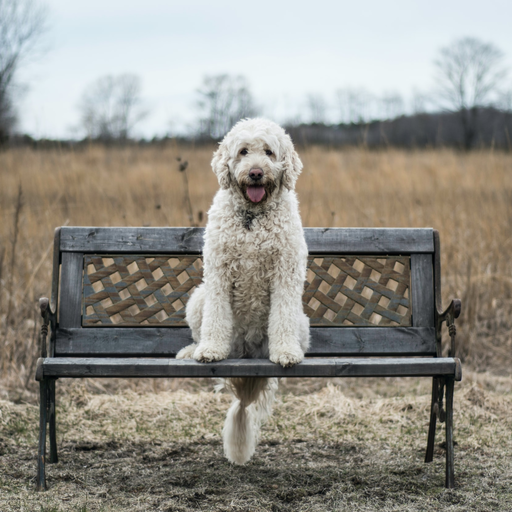

In [12]:
image = download_image(img_url).resize((512, 512))
image

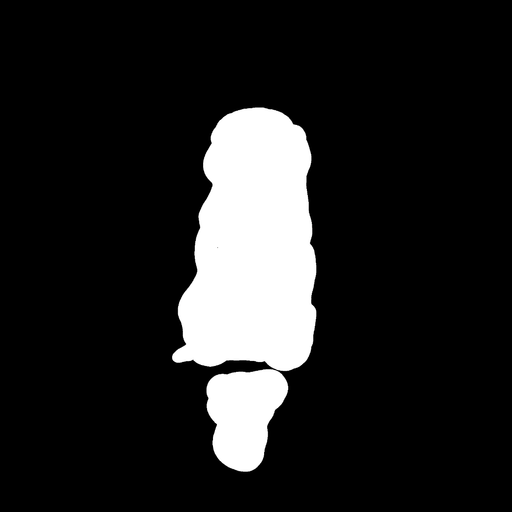

In [13]:
mask_image = download_image(mask_url).resize((512, 512))
mask_image

In [15]:
prompt = "a mecha robot sitting on a bench"

guidance_scale=7.5
num_samples = 3
generator = torch.Generator(device="cuda").manual_seed(42) 

images = pipe(
    prompt=prompt,
    image=image,
    mask_image=mask_image,
    guidance_scale=guidance_scale,
    generator=generator,
    num_images_per_prompt=num_samples,
).images

  0%|          | 0/50 [00:00<?, ?it/s]

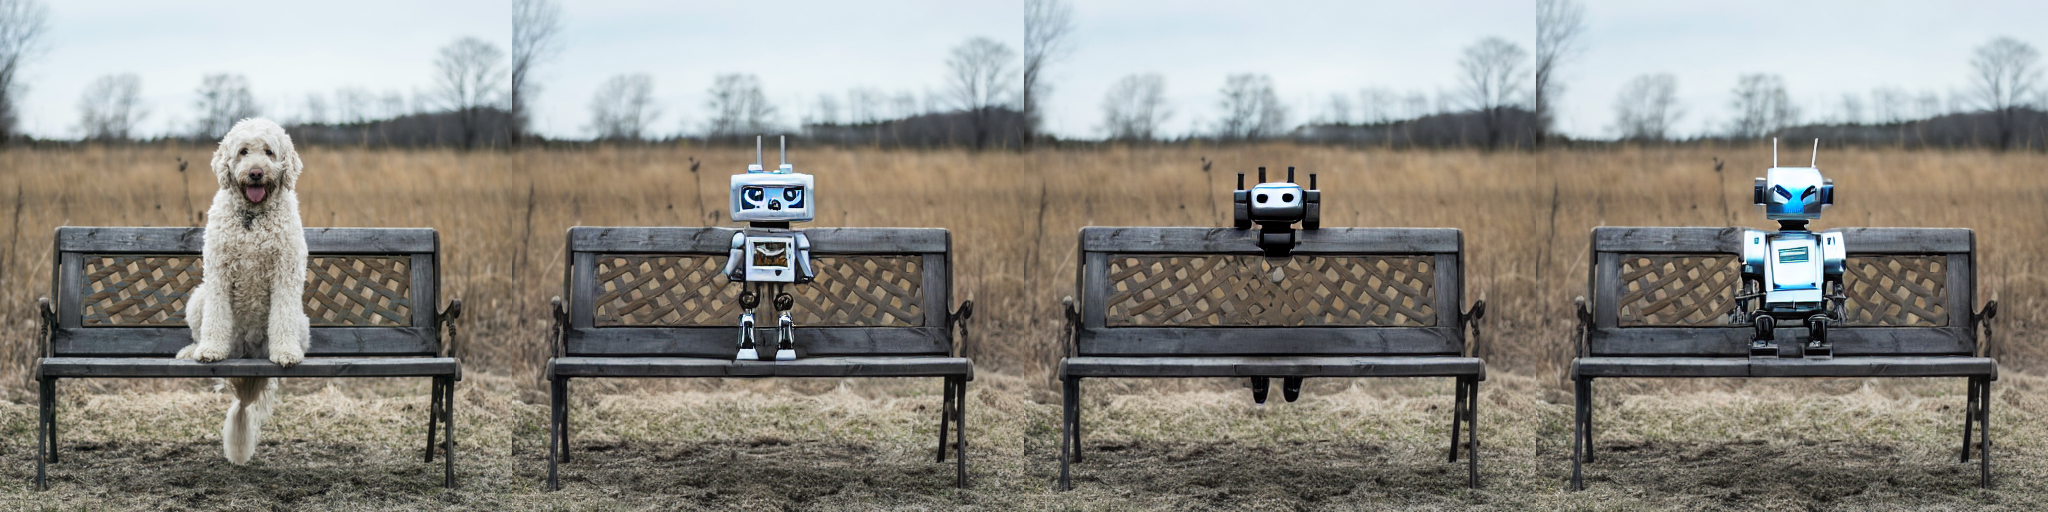

In [16]:
images.insert(0, image)
image_grid(images, 1, num_samples + 1)

The in-painting results will depend on the quality of the input image, the mask, and the prompt. The better the input data, the better the in-painting results will be.

Now, let's create a pipeline that mixes the segmentation proccess with the in-painting process. The idea is to first use a segmentation model to detect the objects in the image and create a mask for the areas that we want to inpaint. Then, we will use the `StableDiffusionInpaintPipeline` to fill in those areas based on the surrounding context and a given prompt.